# 11. 変分推論(ADVI)— 事後を「最適化」で近似する

## この章で分かること

- **サンプリング(MCMC)** と **最適化(変分推論, VI)** という 2 つの推論アプローチ
- VI の目的関数 **ELBO** — ニューラルネット教材の VAE とまったく同じもの
- **ADVI**(自動微分変分推論)を PyMC で動かす
- **平均場近似** の代償(相関・分散の過小評価)と、それでも VI を使う理由

07〜08 章では事後分布を **サンプリング** で近似しました。本章はもう一つの道
— 事後を **単純な分布で近似し、その近さを最適化で詰める** — を扱います。

> **環境メモ**: 08 章と同じく numba バックエンドを使います(`PYTENSOR_FLAGS="cxx=,mode=NUMBA"`)。
> PyMC が無い環境では各セルは案内を表示してスキップします。

```{admonition} 核心 — ひとことで
:class: tip
**変分推論は推論を「最適化」に変える：扱いやすい分布 $q_\phi$ を ELBO 最大化で事後に近づける。**
ELBO を上げる＝KL を下げる＝$q$ を事後に寄せる。これは VAE（nn 08 章）とまったく同じ目的関数。
速いが近似 — 平均場近似は相関を取りこぼし分散を過小評価するので、「速い近似（VI）と遅い正解（MCMC）の使い分け」。
```

In [1]:
import os

os.environ.setdefault("PYTENSOR_FLAGS", "cxx=,mode=NUMBA")

import matplotlib.pyplot as plt
import numpy as np

from bayes_textbook.conjugacy import BetaBinomial

rng = np.random.default_rng(42)
np.set_printoptions(precision=4, suppress=True)

try:
    import arviz as az
    import pymc as pm

    PYMC_OK = True
    print(f"pymc {pm.__version__} / arviz {az.__version__} ready")
except Exception as err:  # noqa: BLE001
    PYMC_OK = False
    print(f"PyMC unavailable ({type(err).__name__}) -> cells will print skip notices")

pymc 6.0.1 / arviz 1.1.0 ready


## 1. なぜもう一つの推論法か

MCMC(07・08 章)は「正しい」事後からサンプルを引ける金字塔ですが、
**モデルが巨大・データが大量** になると遅くなります(各ステップで全データを舐める)。

**変分推論 (Variational Inference, VI)** は発想を変えます。

> 事後 $p(\theta \mid x)$ そのものは諦め、**扱いやすい分布の族 $q_\phi(\theta)$**(例: 独立な正規分布)から
> 「最も事後に近い 1 つ」を **最適化で選ぶ**。

- MCMC: 推論 = **サンプリング**(確率的、漸近的に厳密、遅い)
- VI: 推論 = **最適化**(決定論的、近似、速い・スケールする)

「分布を当てはめるパラメータ $\phi$ を勾配降下で動かす」— ニューラルネットの学習と同じ枠組みです。

## 2. ELBO — 近づける目的関数

$q_\phi$ を事後 $p(\theta \mid x)$ に近づけたい。近さを KL ダイバージェンスで測り、
$\mathrm{KL}(q_\phi \,\|\, p(\theta \mid x))$ を最小化します。これは計算できない $p(x)$ を含みますが、
変形すると **ELBO(変分下界)** の最大化に等しくなります。

$$
\mathrm{ELBO}(\phi) = \mathbb{E}_{q_\phi}[\log p(x, \theta)] - \mathbb{E}_{q_\phi}[\log q_\phi(\theta)]
$$

$$
\log p(x) = \mathrm{ELBO}(\phi) + \mathrm{KL}(q_\phi \,\|\, p(\theta \mid x))
$$

$\log p(x)$ は $\phi$ に依らない定数なので、**ELBO を上げる = KL を下げる = $q$ を事後に近づける**。

これは **08 章(ニューラルネット教材)の VAE の損失とまったく同じ ELBO** です。
VAE は「データ点ごとの $q$ をニューラルネットに予測させる」償却版 VI(§6 で再訪)。

## 3. ADVI を動かす — ベータ二項で答え合わせ

**ADVI(Automatic Differentiation VI)** は、パラメータを制約のない空間に変換し
($\theta \in (0,1)$ なら logit へ)、そこで $q$ を **対角正規分布** と置いて ELBO を勾配上昇で最大化します。
PyMC では `pm.fit(method="advi")` の一行です。03 章の閉形式と突き合わせます。

In [2]:
# ADVI on the beta-binomial posterior; compare to the exact Beta posterior.
exact = BetaBinomial(2, 2).update(34, 16)

if PYMC_OK:
    with pm.Model():
        theta = pm.Beta("theta", 2, 2)
        pm.Binomial("x", n=50, p=theta, observed=34)
        approx = pm.fit(n=20000, method="advi", progressbar=False, random_seed=0)
        idata_advi = approx.sample(4000, random_seed=0)
    advi = idata_advi.posterior["theta"].values.ravel()
    print(f"ADVI : mean={advi.mean():.4f}, sd={advi.std():.4f}")
    print(f"exact: mean={exact.mean:.4f}, sd={exact.dist.std():.4f}")
else:
    print(f"[skipped] exact posterior Beta({exact.alpha:g},{exact.beta:g}), mean={exact.mean:.4f}")

Finished [100%]: Average Loss = 3.6804


ADVI : mean=0.6652, sd=0.0699
exact: mean=0.6667, sd=0.0636


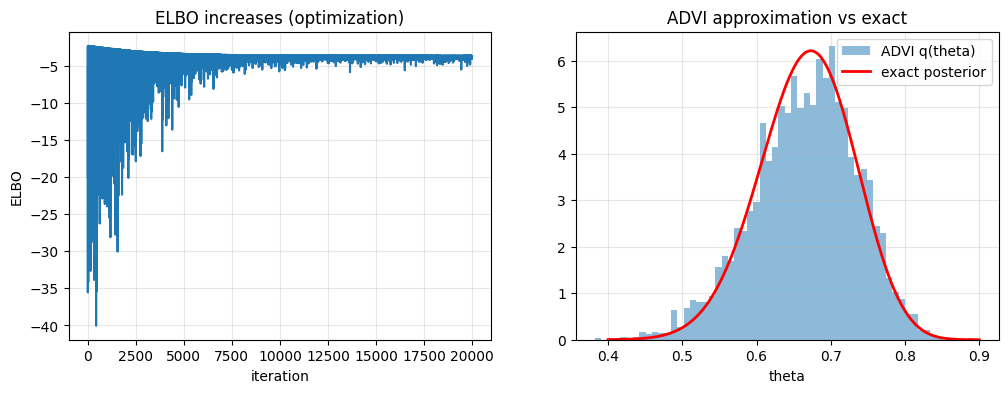

In [3]:
# The ELBO climbs as the optimization makes q closer to the posterior.
if PYMC_OK:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(-approx.hist)             # hist stores the loss (= -ELBO)
    axes[0].set_xlabel("iteration"); axes[0].set_ylabel("ELBO")
    axes[0].set_title("ELBO increases (optimization)"); axes[0].grid(alpha=0.3)
    th = np.linspace(0.4, 0.9, 300)
    axes[1].hist(advi, bins=60, density=True, alpha=0.5, label="ADVI q(theta)")
    axes[1].plot(th, exact.dist.pdf(th), "r", lw=2, label="exact posterior")
    axes[1].set_xlabel("theta"); axes[1].legend(); axes[1].grid(alpha=0.3)
    axes[1].set_title("ADVI approximation vs exact")
    plt.show()
else:
    print("[skipped: PyMC not available]")

### ▶ 触って確かめる — 反復で近似が事後に寄っていく

ADVI の反復回数 $n$ をスライダーで増やすと、近似 $q(\theta)$（実線）が厳密事後（破線）へ寄っていきます。
最適化を進めるほど ELBO が上がり KL が縮む様子の「見える化」です（静的 HTML でも動作）。

In [4]:
# Slider over ADVI iterations: q tightens toward the exact posterior as we optimize.
from bayes_textbook import visualization as viz

if PYMC_OK:
    import plotly.io as pio

    pio.renderers.default = "plotly_mimetype+notebook_connected"
    th = np.linspace(0.4, 0.9, 250)
    frames = []
    for n_it in [50, 200, 1000, 5000, 20000]:
        with pm.Model():
            t_ = pm.Beta("theta", 2, 2)
            pm.Binomial("x", n=50, p=t_, observed=34)
            ap = pm.fit(n=n_it, method="advi", progressbar=False, random_seed=0)
            smp = ap.sample(4000, random_seed=0).posterior["theta"].values.ravel()
        hist, edges = np.histogram(smp, bins=40, range=(0.4, 0.9), density=True)
        centers = 0.5 * (edges[:-1] + edges[1:])
        frames.append((f"{n_it}",
                       [("ADVI q(theta)", np.interp(th, centers, hist), None),
                        ("exact posterior", exact.dist.pdf(th), "dash")]))
    fig = viz.plotly_curve_slider(th, frames, slider_name="ADVI iterations",
                                  title="optimization tightens q toward the posterior")
    fig.update_xaxes(title="theta")
    fig.show()
else:
    print("[skipped: PyMC not available]")

Finished [100%]: Average Loss = 8.3442


Finished [100%]: Average Loss = 9.1264


Finished [100%]: Average Loss = 7.4272


Finished [100%]: Average Loss = 3.912


Finished [100%]: Average Loss = 3.6804


ADVI の平均は厳密事後とほぼ一致。形もよく合っていますが、
logit 空間で正規と仮定した近似なので、裾はわずかにずれます。**速くて近い** が VI の身上です。

## 4. 平均場近似の限界 — 相関を捉えられない

標準の ADVI は $q$ を **各パラメータ独立の正規分布**(平均場近似)と置きます。
そのため、事後にパラメータ間の **相関** があると、それを表現できず、
**分散を過小評価** します。

中心化していない線形回帰 $y = w_0 + w_1 x$ は、$w_0$ と $w_1$ の事後が強く相関する好例です。
ADVI(平均場)と NUTS(相関を捉える)の事後共分散を比べます。

In [5]:
# Uncentered regression -> correlated (w0, w1) posterior. Mean-field ADVI misses it.
x = rng.uniform(5, 10, 40)               # x far from 0 -> w0, w1 anti-correlated
y = 1.0 + 0.5 * x + rng.standard_normal(40)

if PYMC_OK:
    with pm.Model() as reg:
        w0 = pm.Normal("w0", 0, 10)
        w1 = pm.Normal("w1", 0, 10)
        sigma = pm.HalfNormal("sigma", 5)
        pm.Normal("y", w0 + w1 * x, sigma, observed=y)
        idata_nuts = pm.sample(600, tune=600, chains=2, cores=1, random_seed=0, progressbar=False)
        approx_r = pm.fit(n=30000, method="advi", progressbar=False, random_seed=0)
        idata_vi = approx_r.sample(3000, random_seed=0)

    def corr(idata):
        a = idata.posterior["w0"].values.ravel()
        b = idata.posterior["w1"].values.ravel()
        return np.corrcoef(a, b)[0, 1], a.std(), b.std()

    cn, s0n, s1n = corr(idata_nuts)
    cv, s0v, s1v = corr(idata_vi)
    print(f"NUTS : corr(w0,w1)={cn:+.3f}, sd(w0)={s0n:.3f}, sd(w1)={s1n:.3f}")
    print(f"ADVI : corr(w0,w1)={cv:+.3f}, sd(w0)={s0v:.3f}, sd(w1)={s1v:.3f}  <- ~0 corr, smaller sd")
else:
    print("[skipped: PyMC not available]")

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [w0, w1, sigma]


Sampling 2 chains for 600 tune and 600 draw iterations (1_200 + 1_200 draws total) took 1 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


Finished [100%]: Average Loss = 57.898


NUTS : corr(w0,w1)=-0.985, sd(w0)=0.695, sd(w1)=0.089
ADVI : corr(w0,w1)=+0.015, sd(w0)=0.140, sd(w1)=0.018  <- ~0 corr, smaller sd


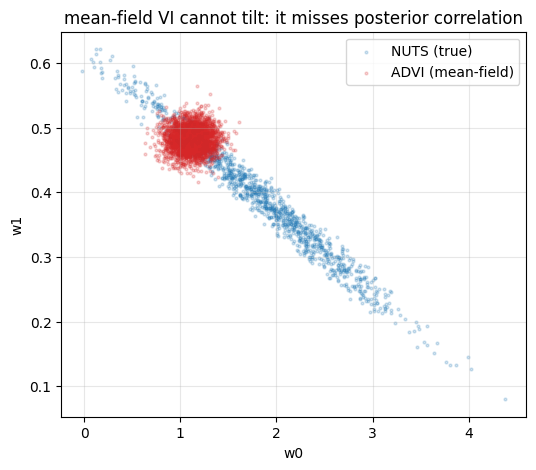

In [6]:
# Visualize: NUTS posterior is a tilted ellipse; mean-field ADVI is axis-aligned.
if PYMC_OK:
    fig, ax = plt.subplots(figsize=(6, 5))
    for idata, name, c in [(idata_nuts, "NUTS (true)", "#1f77b4"), (idata_vi, "ADVI (mean-field)", "#d62728")]:
        a = idata.posterior["w0"].values.ravel()
        b = idata.posterior["w1"].values.ravel()
        ax.scatter(a, b, s=4, alpha=0.2, color=c, label=name)
    ax.set_xlabel("w0"); ax.set_ylabel("w1"); ax.legend(); ax.grid(alpha=0.3)
    ax.set_title("mean-field VI cannot tilt: it misses posterior correlation")
    plt.show()
else:
    print("[skipped: PyMC not available]")

NUTS の事後は傾いた楕円(強い負相関)ですが、ADVI は軸に平行な楕円しか作れず、
相関を取りこぼし、各軸の幅(不確実性)も小さく見積もります。
**点推定や周辺平均には十分でも、相関・同時不確実性が要る用途には注意** が必要です。

## 5. 速度と精度のトレードオフ

VI の見返りは速度 — ただし **それが効くのは規模が大きいとき** です。
下の小モデルでは、ADVI の反復回数(数万ステップ)固定のオーバーヘッドのせいで、
NUTS(数百ドロー)より **むしろ遅い** ことすらあります。
VI の真価は、パラメータ・データが増えて MCMC が現実的でなくなる領域で現れます。

In [7]:
# Wall-clock comparison on the same model (illustrative; VI's edge grows with scale).
import time

if PYMC_OK:
    with reg:
        t0 = time.perf_counter()
        pm.sample(600, tune=600, chains=2, cores=1, random_seed=1, progressbar=False)
        t_nuts = time.perf_counter() - t0
        t0 = time.perf_counter()
        pm.fit(n=30000, method="advi", progressbar=False, random_seed=1)
        t_vi = time.perf_counter() - t0
    print(f"NUTS: {t_nuts:.1f} s   ADVI: {t_vi:.1f} s")
    print("On big hierarchical / deep models the gap becomes orders of magnitude.")
else:
    print("[skipped: PyMC not available]")

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [w0, w1, sigma]


Sampling 2 chains for 600 tune and 600 draw iterations (1_200 + 1_200 draws total) took 1 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


Finished [100%]: Average Loss = 57.974


NUTS: 1.3 s   ADVI: 2.4 s
On big hierarchical / deep models the gap becomes orders of magnitude.


## 6. VAE との橋 — 償却変分推論

ニューラルネット教材 08 章の **VAE** は、実は変分推論そのものです。

| | 本章の ADVI | VAE(nn 08 章) |
|---|---|---|
| 近似分布 $q$ | パラメータ $\phi$ を直接最適化 | **エンコーダ網が $q$ の $(\mu, \sigma)$ を予測** |
| 目的関数 | ELBO | ELBO(再構成 $-$ KL) |
| 対象 | 1 つの事後 | データ点ごとの潜在の事後 |

VAE は「データ点ごとに $\phi$ を最適化し直す代わりに、$\phi$ を出力する関数(エンコーダ)を学習する」
**償却(amortized)変分推論**。reparameterization trick も ADVI の勾配推定と同じ発想です。
**ベイズ推論とニューラルネットは、ELBO という同じ目的関数で繋がっています。**

## 7. いつ VI / いつ MCMC

| 状況 | 推奨 |
|---|---|
| 小〜中モデル、正確さ最優先 | **MCMC(NUTS)** |
| 巨大モデル・大量データ・速度優先 | **VI(ADVI)** |
| 相関・裾・多峰性が重要 | **MCMC**(平均場 VI は苦手) |
| 深層生成モデル(VAE 等) | **VI**(償却) |
| 探索的に素早く回したい | VI で当たりをつけ、最後に MCMC で確認 |

VI は「速い近似」、MCMC は「遅い正解」。両者は競合ではなく **使い分け** です。

## 8. まとめ

- VI は推論を **最適化** に変える: 単純な $q_\phi$ を ELBO 最大化で事後に近づける。
- **ELBO** は VAE(nn 08 章)とまったく同じ目的関数。ベイズと深層学習を繋ぐ。
- **ADVI** は PyMC で `pm.fit(method="advi")` の一行。平均は正確、速い。
- **平均場近似** は相関を取りこぼし分散を過小評価する — 用途を選ぶ。
- 速い近似(VI)と遅い正解(MCMC)を使い分ける。

## 9. Exercises

1. §3 の ADVI で `n`(反復数)を 2000 / 20000 / 50000 と変え、ELBO と事後の収束を見よ。
2. §4 の回帰で $x$ を中心化($x - \bar{x}$)してから ADVI を実行し、
   相関が消えて平均場近似がうまく合うことを確認せよ。
3. ベータ二項で事前を $\mathrm{Beta}(20,20)$ に変え、ADVI 近似が閉形式とどれだけ合うか調べよ。
4. `method="fullrank_advi"`(全ランク VI)を使うと §4 の相関を捉えられるか確認せよ。
5. (発展)階層モデル(06 章の店舗 CVR)に ADVI を適用し、NUTS の店舗別推定と比較せよ。

```{admonition} 実社会では
:class: important
VI は「MCMC が遅すぎる規模」で事後を近似する実用解です。

- 大規模・大量データ・深層生成（VAE・確率的トピックモデル）→ ADVI / 償却 VI。
- 探索フェーズで VI で当たりをつけ、最終確認は MCMC、という二段構えが定石。
- 落とし穴：平均場は相関・裾・多峰性に弱い → 同時不確実性が要る用途は full-rank VI か MCMC。
```